In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

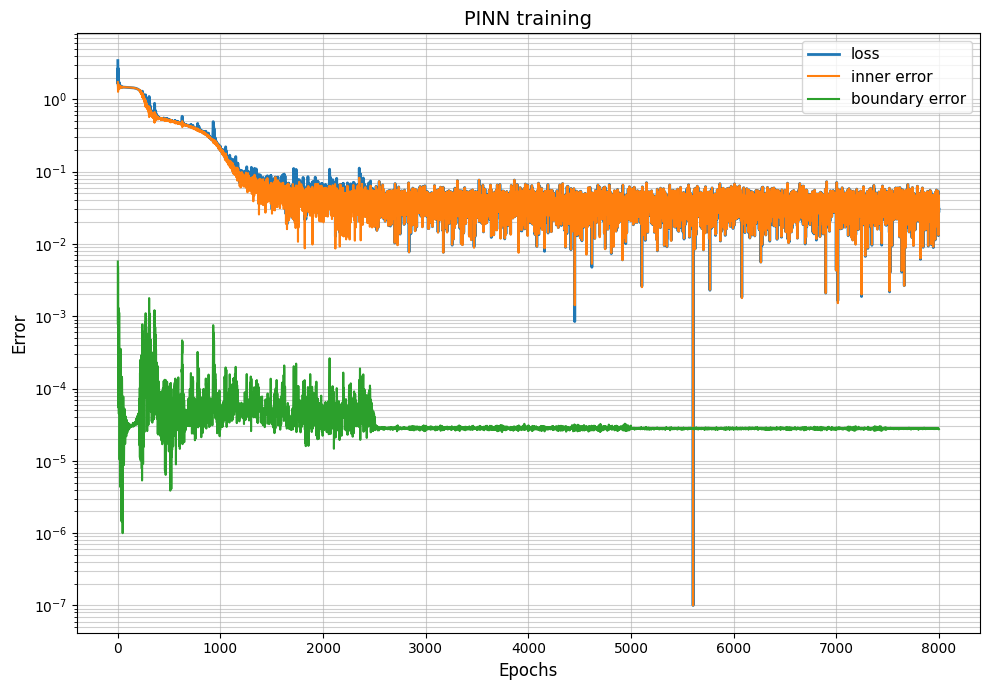

In [6]:
def plot_combined_loss(pinn_poisson):
    try:
        history = torch.load(pinn_poisson)
    except FileNotFoundError:
        print(f"Файл {pinn_poisson} не найден.")
        return

    epochs = range(len(history['total']))
    
    raw_total = np.array(history['total'])
    raw_integral = np.array(history['integral'])
    
    min_total = np.min(raw_total)
    min_integral = np.min(raw_integral)
    
    total_loss_gap = raw_total - min_total + 1e-7
    inner_error_gap = raw_integral - min_integral + 1e-7
    boundary_error = history['bc']

    plt.figure(figsize=(10, 7))

    plt.plot(epochs, total_loss_gap, label='loss', linewidth=2)
    plt.plot(epochs, inner_error_gap, label='inner error', linewidth=1.5)
    plt.plot(epochs, boundary_error, label='boundary error', linewidth=1.5)

    plt.yscale('log')
    
    plt.grid(True, which="both", ls="-", alpha=0.6)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.title('PINN training', fontsize=14)
    plt.legend(loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.savefig('pinn_training_log_fixed.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_combined_loss("train_history.pt")